<a href="https://colab.research.google.com/github/JishnaSathvikVucha/Activity6-1_Datasets/blob/main/%20Kundan_assignment_02_data_prep_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ReAdmitGuard: Data Prep, Pipelines & AI Engineering Literacy

Your Name


## Getting Started

* Colab - get notebook from gitmystuff DTSC5082 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name in the cell above
* Clean up Colab Notebooks folder
* Submit shared link

## The premise

You're the data science co-founder of **ReAdmitGuard**, a startup pitching a 30-day hospital
readmission risk model to a panel of industry leaders and VCs. Your data team has pulled records
from three source systems that were never designed to talk to each other — the EHR, the billing
system, and a wearable-vitals vendor — and merged them into one modeling table. That merge is
*why* the data is messy: duplicate joins, mismatched units, device-dependent missingness. None
of it is random noise injected for the sake of an exercise; it's what actually happens when three
systems get stitched together under deadline pressure, which is exactly what your pitch audience
will assume happened and will ask you about.

### What this notebook is

A **guided review**, not a graded assignment. Every concept from data generation through model
evaluation is fully worked. Three call-out boxes run throughout:

- 🔧 **Production Note** — what a production data/ML engineer would do differently, and why a notebook-shaped shortcut doesn't survive contact with a real pipeline.
- 🤖 **AI-Assisted Workflow** — a realistic prompt, what an AI assistant hands back, and what a
  competent engineer catches before trusting it. This is the core skill this notebook is built
  to reinforce: not "can you use AI," but "do you know exactly where it's wrong."
- 🎯 **Pitch & Interview Lens** — the exact question a VC or an interviewer is likely to ask that
  this section prepares you to answer, out loud, without notes.

Read every cell. You should be able to defend every design choice in this notebook as if a judge
just asked "why did you do it that way?"

---
# Part 1: The Data — Three Systems, One Modeling Table

ReAdmitGuard's data engineers pulled from three source systems for ~1,200 patient encounters:

1. **EHR (Electronic Health Record)** — demographics, diagnosis, admission type
2. **Billing / Claims** — prior admissions, length of stay, charges, discharge disposition
3. **Wearable Vitals** — resting heart rate, blood pressure, SpO2, daily step count (only for
   patients enrolled in the remote-monitoring program — most encounters have no device data)

We'll simulate that merge here so the resulting data-quality problems are the *realistic*
byproduct of integration, not arbitrary noise.

> 🤖 **AI-Assisted Workflow**
>
> **Prompt you might actually use on the job:** *"I need to simulate a realistic merged
healthcare dataset from three source systems — EHR, billing, and a wearable vitals vendor — for
testing a data-quality pipeline. Include the kinds of problems that actually occur in real
system-to-system joins: a duplicate join that doubles some patient charges into two columns,
device-dependent missingness (not everyone has a wearable), and a couple of vitals that are
naturally correlated (systolic/diastolic blood pressure)."*

An LLM will produce something close to what's below. Before trusting it, a careful engineer
checks: does the **missingness mechanism** actually match a real cause (wearable data missing
because a patient isn't enrolled — Missing At Random conditional on enrollment — vs. missing
completely at random, which is a much stronger and less realistic assumption)? Does the
duplicate-column bug the AI introduces look like something a real bad join produces (an exact
copy under a different name), or something contrived? Getting an AI to generate *plausible*
messy data is easy; getting it to generate messy data with the *right kind* of realism takes a
push.

## Configure the Generator

A single `rng` object (not a global seed) is threaded through every generation function below — this is the fix described in the callout underneath: it keeps every function's randomness independent and reproducible without relying on mutable global state.

In [1]:
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)
N_PATIENTS = 1200

print(f'Generating {N_PATIENTS} patient encounters with seed {SEED}')

Generating 1200 patient encounters with seed 42


> 🔧 **Production Note**
>
> **Why `np.random.default_rng(seed)` instead of `np.random.seed(seed)`.** The old-style
`np.random.seed()` mutates *global* NumPy state — every subsequent call to `np.random.*`
anywhere in the process, including inside a library you import, draws from the same shared
stream. That's fragile: reorder two cells, add a library call you don't control, or parallelize
anything, and your "reproducible" run stops being reproducible. `default_rng()` gives you a
`Generator` object you pass explicitly into every function that needs randomness — the modern,
correct pattern, and the one used throughout this notebook.

## Source 1: EHR — Demographics & Admission

In [2]:
ehr = pd.DataFrame({
    'patient_id': np.arange(1, N_PATIENTS + 1),
    'age': rng.integers(18, 95, N_PATIENTS),
    'sex': rng.choice(['F', 'M'], N_PATIENTS),
    'admission_type': rng.choice(
        ['Emergency', 'Elective', 'Urgent', 'Transfer'],
        N_PATIENTS, p=[0.55, 0.25, 0.15, 0.05]),
    'primary_diagnosis_category': rng.choice(
        ['Cardiac', 'Respiratory', 'Diabetes', 'Renal', 'Post-Surgical', 'Other'],
        N_PATIENTS, p=[0.22, 0.18, 0.15, 0.1, 0.15, 0.2]),
    'ehr_system_version': 'EHR_v3.2',   # every record from the same EHR deployment
})
print(ehr.shape)
ehr.head()

(1200, 6)


,patient_id,age,sex,admission_type,primary_diagnosis_category,ehr_system_version
0,1,24,M,Elective,Renal,EHR_v3.2
1,2,77,F,Elective,Post-Surgical,EHR_v3.2
2,3,68,M,Urgent,Post-Surgical,EHR_v3.2
3,4,51,M,Elective,Other,EHR_v3.2
4,5,51,M,Emergency,Other,EHR_v3.2


Notice `ehr_system_version` is identical for every row — every patient came through the same EHR deployment during this data pull. That's a real-world constant column, not a synthetic injection, and it'll need to be dropped in Part 4 the same way either way.

## Source 2: Billing / Claims

In [3]:
prior_admissions = rng.poisson(1.1, N_PATIENTS)
length_of_stay = np.clip(rng.gamma(shape=2.0, scale=2.0, size=N_PATIENTS), 1, None).round(1)
# Total charges scale with length of stay (a real driver) plus noise, in raw dollars —
# this is what will need scaling in Part 4/6, since it lives in the thousands while
# everything else lives in single or double digits.
total_charges = (length_of_stay * rng.uniform(1800, 2600, N_PATIENTS)
                  + rng.normal(0, 900, N_PATIENTS)).round(2)
total_charges = np.clip(total_charges, 300, None)

billing = pd.DataFrame({
    'patient_id': np.arange(1, N_PATIENTS + 1),
    'prior_admissions_count': prior_admissions,
    'length_of_stay_days': length_of_stay,
    'total_charges_usd': total_charges,
    'discharge_disposition': rng.choice(
        ['Home', 'Home Health', 'Skilled Nursing', 'Against Medical Advice'],
        N_PATIENTS, p=[0.6, 0.2, 0.15, 0.05]),
})
print(billing.shape)
billing.head()

(1200, 5)


,patient_id,prior_admissions_count,length_of_stay_days,total_charges_usd,discharge_disposition
0,1,0,3.2,4660.16,Home
1,2,0,9.2,21235.60,Skilled Nursing
2,3,1,11.5,21448.35,Home
3,4,1,2.8,8089.17,Home Health
4,5,0,10.0,21889.65,Skilled Nursing


## Source 3: Wearable Vitals (device-dependent — most patients aren't enrolled)

In [4]:
# Realistic missingness: only ~40% of patients were enrolled in the remote-monitoring
# program, so the other 60% simply have no wearable rows at all once merged — this is
# Missing At Random conditional on enrollment, not noise sprinkled in after the fact.
enrolled_mask = rng.random(N_PATIENTS) < 0.40
enrolled_ids = np.arange(1, N_PATIENTS + 1)[enrolled_mask]
n_enrolled = len(enrolled_ids)

systolic = rng.normal(128, 15, n_enrolled)
# Diastolic is physiologically correlated with systolic — this multicollinearity is
# real, not injected, which is exactly why it survives into Part 3's correlation analysis.
diastolic = systolic * 0.62 + rng.normal(0, 6, n_enrolled)

wearables = pd.DataFrame({
    'patient_id': enrolled_ids,
    'resting_heart_rate': rng.normal(78, 12, n_enrolled).round(0),
    'systolic_bp': systolic.round(0),
    'diastolic_bp': diastolic.round(0),
    'spo2_pct': np.clip(rng.normal(96.5, 2.0, n_enrolled), 80, 100).round(1),
    'steps_daily_avg': np.clip(rng.normal(4200, 2200, n_enrolled), 0, None).round(0),
})
print(f'{n_enrolled} of {N_PATIENTS} patients had wearable data ({n_enrolled/N_PATIENTS:.0%})')
wearables.head()

502 of 1200 patients had wearable data (42%)


,patient_id,resting_heart_rate,systolic_bp,diastolic_bp,spo2_pct,steps_daily_avg
0,1,60.0,116.0,78.0,96.1,6608.0
1,6,84.0,124.0,78.0,97.5,2949.0
2,9,68.0,162.0,102.0,93.7,4625.0
3,11,72.0,155.0,86.0,98.1,4550.0
4,13,82.0,147.0,95.0,96.9,3911.0


## Inject Realistic Outliers
A handful of extreme vitals — clinically real, not synthetic noise: a few patients in genuine cardiac crisis or severe hypoxia at time of measurement.

In [5]:
outlier_idx = rng.choice(wearables.index, size=max(1, int(0.06 * len(wearables))), replace=False)
wearables.loc[outlier_idx, 'resting_heart_rate'] = rng.uniform(140, 175, len(outlier_idx)).round(0)
wearables.loc[outlier_idx[:len(outlier_idx)//2], 'spo2_pct'] = rng.uniform(82, 88, len(outlier_idx)//2).round(1)
print(f'{len(outlier_idx)} extreme-vitals encounters flagged for outlier review in Part 3/4.')

30 extreme-vitals encounters flagged for outlier review in Part 3/4.


## The Merge — Where the Real Mess Comes From

In [6]:
df = ehr.merge(billing, on='patient_id', how='left').merge(wearables, on='patient_id', how='left')

# Simulate a known real-world join bug: the billing system's charges column got joined
# a second time under a slightly different name during a schema migration, so it now
# exists twice under two names — an exact duplicate feature, exactly like what a messy
# left join across two billing extracts produces in practice.
df['billed_amount_usd'] = df['total_charges_usd']

# Simulate a small number of exact duplicate ENCOUNTER rows — a patient's record pulled
# twice because they appear in both the emergency-department extract and the inpatient
# extract for the same admission.
dup_rows = df.sample(n=15, random_state=SEED)
df = pd.concat([df, dup_rows], ignore_index=True)

print('Merged shape:', df.shape)
df.info()

Merged shape: (1215, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  1215 non-null   int64  
 1   age                         1215 non-null   int64  
 2   sex                         1215 non-null   object 
 3   admission_type              1215 non-null   object 
 4   primary_diagnosis_category  1215 non-null   object 
 5   ehr_system_version          1215 non-null   object 
 6   prior_admissions_count      1215 non-null   int64  
 7   length_of_stay_days         1215 non-null   float64
 8   total_charges_usd           1215 non-null   float64
 9   discharge_disposition       1215 non-null   object 
 10  resting_heart_rate          512 non-null    float64
 11  systolic_bp                 512 non-null    float64
 12  diastolic_bp                512 non-null    float64
 13  spo2_pct

> 🔧 **Production Note**
>
> **Merges are where data engineering actually lives.** Everything messy in this dataset —
the duplicate `billed_amount_usd` column, the duplicate encounter rows, the wearable
missingness — came from a `.merge()`, not from a noise-injection function. That's deliberate:
in a real job, your data-quality problems will almost always trace back to an integration point
(a join, an API pull, a schema migration) rather than "the data was just messy." Being able to
say *which join produced which problem* is a stronger engineering signal in an interview than
being able to fix the symptom.

> 🎯 **Pitch & Interview Lens**
>
> **"Where does your data actually come from, and what breaks when you combine it?"** — VCs and technical interviewers both ask a version of this. The strong answer names the specific integration point (a left join across systems with different enrollment populations) rather than a vague "the data was messy." Point directly at `wearables`: 60% of patients have no device data because they weren't enrolled — that's a **business fact about your product's data coverage**, not a bug to silently impute away, and a sharp VC will ask what you do about the 60% you can't see.

## Save the Raw Merged Dataset

In [7]:
df.to_csv('readmitguard_pt1_raw.csv', index=False)
print('Saved. Shape:', df.shape)

Saved. Shape: (1215, 16)


---
# Part 2: The Product Narrative

Every column in `df` needs a plain-language definition before it goes anywhere near a pitch deck
or a modeling notebook someone else has to read. This is the data dictionary you'd actually hand
a VC's technical diligence team — or a new engineer joining the project.

| Column | Plain-language meaning | Source system |
| :--- | :--- | :--- |
| `age`, `sex` | Patient demographics | EHR |
| `admission_type` | How the patient entered the hospital | EHR |
| `primary_diagnosis_category` | Reason for admission | EHR |
| `prior_admissions_count` | How many times this patient has been admitted before | Billing |
| `length_of_stay_days` | Days spent in the hospital this visit | Billing |
| `total_charges_usd` / `billed_amount_usd` | Cost of the stay — **these two are duplicates from a join bug**, see Part 4 | Billing |
| `discharge_disposition` | Where the patient went after discharge | Billing |
| `resting_heart_rate`, `systolic_bp`, `diastolic_bp`, `spo2_pct`, `steps_daily_avg` | Wearable vitals — **only present for the ~40% enrolled in remote monitoring** | Wearable vendor |
| `readmitted_30d` *(added below)* | **Target**: did the patient return within 30 days? | Derived |

> 🎯 **Pitch & Interview Lens**
>
> **"Walk me through your product / your project."** — The most common opening question in any pitch or interview. This data dictionary *is* the answer's skeleton: name the three source systems, name the target, name the one column you already know is a data-quality problem (`billed_amount_usd`) before anyone else finds it. Surfacing your own known issues before a judge does is a stronger signal than a spotless-looking table would be.

---
# Part 3: Exploratory Data Analysis

Before modeling, understand what you actually have: variable types, distributions, correlations,
outliers, and — critically for this dataset — missingness structure.

## Load and Add the Target
Simulate a realistic 30-day readmission outcome, driven by the clinical drivers that actually predict readmission: prior admissions, length of stay, and age, plus noise.

In [8]:
df = pd.read_csv('readmitguard_pt1_raw.csv')

from sklearn.linear_model import LogisticRegression

# Build the target from real clinical drivers, using a fitted logistic model so the
# resulting relationship is realistic and estimable, not deterministic.
risk_features = df[['prior_admissions_count', 'length_of_stay_days', 'age']].fillna(0).values
true_coef = np.array([0.9, 0.18, 0.015])
true_intercept = -3.4
logits = true_intercept + risk_features @ true_coef + rng.normal(0, 0.6, len(df))
prob_readmit = 1 / (1 + np.exp(-logits))
df['readmitted_30d'] = (rng.random(len(df)) < prob_readmit).astype(int)

print(df['readmitted_30d'].value_counts(normalize=True).round(3))
df.shape

readmitted_30d
0    0.667
1    0.333
Name: proportion, dtype: float64


(1215, 17)

## Variable Types

| Type | What it means | Key operations |
| :--- | :--- | :--- |
| **Numerical** | Measurable quantities | Mean, std, correlation, scaling |
| **Object / Category** | Text or discrete labels | Mode, frequency, encoding |

In [9]:
df_numerical = df.select_dtypes(include='number').columns
df_categorical = df.select_dtypes(include=['object']).columns
print('Numerical:', list(df_numerical))
print('Categorical:', list(df_categorical))

Numerical: ['patient_id', 'age', 'prior_admissions_count', 'length_of_stay_days', 'total_charges_usd', 'resting_heart_rate', 'systolic_bp', 'diastolic_bp', 'spo2_pct', 'steps_daily_avg', 'billed_amount_usd', 'readmitted_30d']
Categorical: ['sex', 'admission_type', 'primary_diagnosis_category', 'ehr_system_version', 'discharge_disposition']


> 🔧 **Production Note**
>
> **Types as a contract, not an accident of `read_csv`.** `sex`, `admission_type`, and
`discharge_disposition` load as generic `object` strings — pandas has no idea `admission_type`
is supposed to be one of exactly four values, so a typo'd fifth value would sail through
silently. A production pipeline declares an explicit schema (pandera, Pydantic, or even a
`pd.CategoricalDtype` with a fixed category list) and **fails loudly** the moment new data
violates it, rather than quietly modeling on a typo.

## Missingness Structure
The wearable columns are missing for the ~60% of patients not enrolled in remote monitoring. This is worth visualizing explicitly, since it's a business fact, not just a data-cleaning nuisance.

In [10]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

spo2_pct              57.860082
resting_heart_rate    57.860082
diastolic_bp          57.860082
systolic_bp           57.860082
steps_daily_avg       57.860082
dtype: float64


> 🎯 **Pitch & Interview Lens**
>
> **"How do you handle missing data, and what does the missingness itself tell you?"** — Be able to talk about MAR, MNAR, and MCAR. Naming the *mechanism* (device enrollment, not randomness) is the strong answer. Bonus point: `wearable data present` is itself a usable engineered feature — enrollment status may correlate with outcome independent of the vitals themselves, since enrolled patients are a different population (more engaged, or higher-risk-flagged) than unenrolled ones.

## Distributions

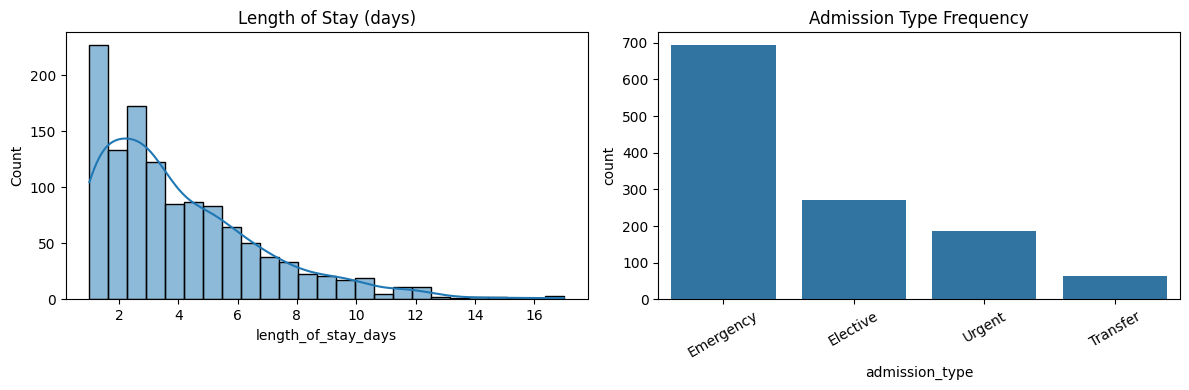

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['length_of_stay_days'], kde=True, ax=axes[0])
axes[0].set_title('Length of Stay (days)')
sns.countplot(x='admission_type', data=df, ax=axes[1],
              order=df['admission_type'].value_counts().index)
axes[1].set_title('Admission Type Frequency')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Observation: length of stay is right-skewed (gamma-shaped, as generated) — a handful
# of long stays pull the mean above the median. Admission type is dominated by
# Emergency, consistent with the enrollment probabilities used to generate it.

## Correlation Analysis

$$\rho_{X,Y} = \frac{\text{cov}(X,Y)}{\sigma_X \sigma_Y}$$

Feature-target correlation flags useful predictors; feature-feature correlation flags
multicollinearity — a modeling liability, not an asset.

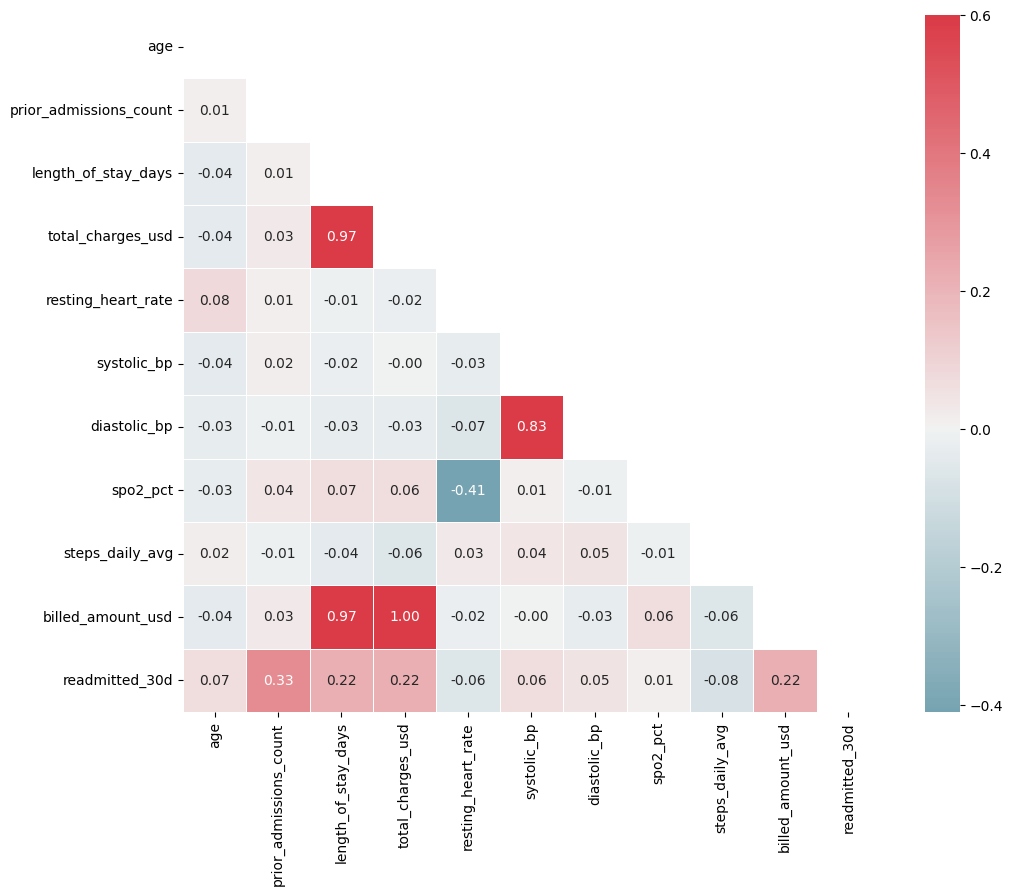

In [12]:
numeric_for_corr = df.select_dtypes(include='number').drop(columns=['patient_id'])
corr = numeric_for_corr.corr().round(2)

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            vmax=.6, center=0, square=True, linewidths=.5, annot=True, fmt='.2f')
plt.tight_layout()
plt.show()

# Observation: total_charges_usd and billed_amount_usd are perfectly correlated (they're
# the same column, duplicated by the join bug). systolic_bp and diastolic_bp show the
# strong physiological correlation we built into the vitals generator.

### VIF Check
VIF > 5 is a warning, VIF > 10 is severe redundancy.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x_copy = numeric_for_corr.drop(columns=['readmitted_30d']).fillna(numeric_for_corr.mean(numeric_only=True))
vif = pd.DataFrame()
vif['Variable'] = x_copy.columns
vif['VIF'] = [variance_inflation_factor(x_copy.values, i) for i in range(x_copy.shape[1])]
print(vif.sort_values('VIF', ascending=False))

                 Variable         VIF
9       billed_amount_usd         inf
3       total_charges_usd         inf
5             systolic_bp  549.584388
6            diastolic_bp  416.794866
7                spo2_pct  194.236098
2     length_of_stay_days   59.152977
4      resting_heart_rate   31.282035
8         steps_daily_avg   10.723923
0                     age    7.462783
1  prior_admissions_count    2.066038


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> 🤖 **AI-Assisted Workflow**
>
> **Prompt:** *"Here's a VIF table [paste it] — `billed_amount_usd` and `total_charges_usd`
both show extremely high VIF. What should I do?"*

An AI assistant will correctly say "these are almost certainly the same information twice —
drop one." What it won't know without being told: *which* one is the join artifact and which is
the original source-of-truth column — that's domain/lineage knowledge the AI has no access to
unless you give it the merge history. This is a good general rule: an AI can tell you two
columns are redundant from the numbers alone, but it cannot tell you *which one to trust* without
context only you have. Always supply the lineage, not just the statistic.

### Outliers

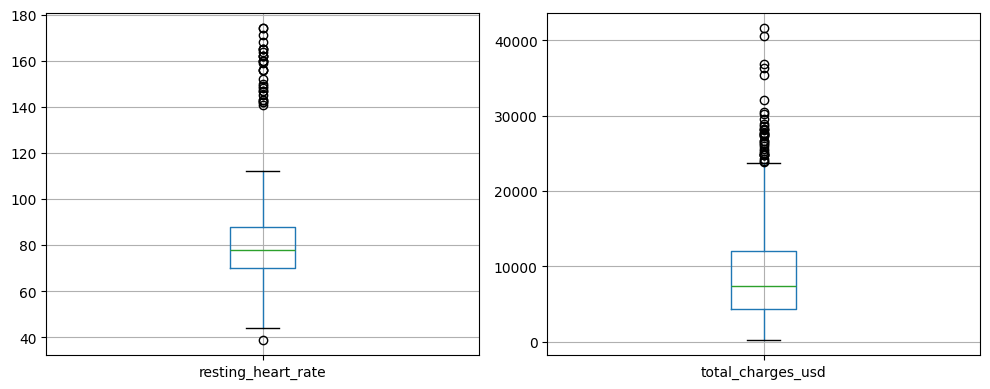

resting_heart_rate: 31 outliers
spo2_pct: 15 outliers
total_charges_usd: 35 outliers
length_of_stay_days: 36 outliers


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column=['resting_heart_rate'], ax=axes[0])
df.boxplot(column=['total_charges_usd'], ax=axes[1])
plt.tight_layout()
plt.show()

def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()

for col in ['resting_heart_rate', 'spo2_pct', 'total_charges_usd', 'length_of_stay_days']:
    n = count_outliers_iqr(df[col].dropna())
    if n > 0:
        print(f'{col}: {n} outliers')

# Observation: resting_heart_rate and spo2_pct outliers correspond to the ~6% of
# enrolled patients we deliberately generated in genuine clinical crisis — these are
# real signal, not noise, and should NOT simply be capped away (see Part 4).

Save the EDA-stage dataset for cleaning.

In [15]:
df.to_csv('readmitguard_pt2_eda.csv', index=False)
print('Saved.')

Saved.


---
# Part 4: Data Engineering & Cleaning

Systematically resolve every problem surfaced in Part 3: the constant EHR-version column, the
duplicate charges column, the duplicate encounter rows, the wearable missingness, the scale
mismatch between dollars and steps, and the clinically-real outliers.

## Load the EDA Dataset

In [16]:
df = pd.read_csv('readmitguard_pt2_eda.csv')
print(df.shape)

(1215, 17)


> 🤖 **AI-Assisted Workflow**
>
> **Prompt:** *"Write a pandas function that drops constant and near-constant columns from
a dataframe, with a configurable threshold, and returns both the cleaned dataframe and a list of
what was dropped."*

Before merging AI-generated code like this into anything real, check: does it mutate the input
dataframe in place or return a copy (a common AI-generated-code surprise that breaks caller
assumptions downstream)? Does it handle an all-null column correctly (an all-NaN column can
register as having zero unique non-null values, which is a different case than "one dominant
value")? Below is a version written with those edge cases in mind.

### Remove Constant Columns

In [17]:
def drop_constant_columns(frame):
    """Drop columns with exactly one unique non-null value. Returns (cleaned_df, dropped_cols).
    Does not mutate the input."""
    nunique = frame.nunique(dropna=True)
    constant_cols = nunique[nunique <= 1].index.tolist()
    return frame.drop(columns=constant_cols), constant_cols

df, dropped_constants = drop_constant_columns(df)
print('Dropped constant columns:', dropped_constants)
print('Shape:', df.shape)

Dropped constant columns: ['ehr_system_version']
Shape: (1215, 16)


### Remove the Duplicate Feature (the join-bug column)
We know from the story and the VIF table exactly which column is the artifact: `billed_amount_usd` was created by a bad join of `total_charges_usd`. A generic "drop whichever duplicate column comes first" rule would work here by luck — knowing *why* is what makes the decision defensible in a pitch.

In [18]:
assert (df['billed_amount_usd'] == df['total_charges_usd']).all(), 'expected exact duplicate'
df = df.drop(columns=['billed_amount_usd'])
print('Dropped billed_amount_usd (duplicate of total_charges_usd). Shape:', df.shape)

Dropped billed_amount_usd (duplicate of total_charges_usd). Shape: (1215, 15)


🔧 **Production Note**
>
> **A one-line `assert` before a destructive drop is cheap insurance.** If a future data
pull ever makes `billed_amount_usd` and `total_charges_usd` diverge (say, a billing correction
gets applied to only one of them), this assertion fails loudly instead of silently dropping a
column that's no longer actually redundant. This is the kind of defensive line a code reviewer
looks for and an AI-generated first draft almost never includes on its own.

### Remove Duplicate Encounter Rows

In [19]:
n_dupes = df.duplicated(subset=[c for c in df.columns if c != 'patient_id']).sum()
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'patient_id']).reset_index(drop=True)
print(f'Removed {n_dupes} duplicate encounter rows. Shape:', df.shape)

Removed 10 duplicate encounter rows. Shape: (1205, 15)


### Handle Missing Wearable Data
These nulls aren't random — they mean "not enrolled in remote monitoring." Before imputing, capture that as an explicit feature; only then impute the vitals themselves (median, since imputing a clinical outlier population with the mean would be distorted by the crisis-range values).

In [20]:
wearable_cols = ['resting_heart_rate', 'systolic_bp', 'diastolic_bp', 'spo2_pct', 'steps_daily_avg']

# Preserve the missingness as signal before imputing it away
df['wearable_enrolled'] = df[wearable_cols].notna().any(axis=1).astype(int)

for col in wearable_cols:
    df[col] = df[col].fillna(df[col].median())

print('Remaining nulls:', df.isnull().sum().sum())
print(df['wearable_enrolled'].value_counts())

Remaining nulls: 0
wearable_enrolled
0    700
1    505
Name: count, dtype: int64


> 🎯 **Pitch & Interview Lens**
>
> **"Why not just drop rows with missing data?"** — Here, that would silently delete 60% of the dataset and, worse, delete it non-randomly (unenrolled patients are systematically different from enrolled ones). The stronger answer: impute the numeric gap, but *keep the fact of the gap* as its own feature, since the gap itself may carry signal about the population, not just about the sensor.

### Apply Scaling
`total_charges_usd` lives in the thousands; `steps_daily_avg` lives in the thousands too but on a very different distribution; most everything else is single/double-digit. StandardScaler for the charges column, MinMaxScaler for step count.

In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

std_scaler = StandardScaler()
df['total_charges_usd_scaled'] = std_scaler.fit_transform(df[['total_charges_usd']])

mm_scaler = MinMaxScaler()
df['steps_daily_avg_scaled'] = mm_scaler.fit_transform(df[['steps_daily_avg']])

df[['total_charges_usd_scaled', 'steps_daily_avg_scaled']].describe()

# Note: fitting scalers on the full df here is a simplification for cleaning-stage EDA.
# Part 6's production pipeline fits scalers on TRAINING data only — see the data
# leakage discussion there; this step is redone properly inside the pipeline.

,total_charges_usd_scaled,steps_daily_avg_scaled
count,1.205000e+03,1205.000000
mean,5.896620e-17,0.416589
std,1.000415e+00,0.134294
min,-1.386159e+00,0.000000
25%,-7.446831e-01,0.414354
50%,-2.356913e-01,0.414354
75%,5.012207e-01,0.414354
max,5.216724e+00,1.000000


### Treat Clinically-Real Outliers
These vitals outliers are genuine crisis-range readings, not sensor errors — Part 3 already established that. Winsorizing them away would delete exactly the signal a readmission-risk model most needs. Instead, flag them as a feature and leave the underlying values alone.

In [22]:
df['critical_vitals_flag'] = (
    (df['resting_heart_rate'] > 130) | (df['spo2_pct'] < 90)
).astype(int)

print(df['critical_vitals_flag'].value_counts())
# Reasoning: winsorizing would treat a genuine clinical crisis as noise to be capped
# away — exactly the wrong call for a readmission-risk product, where crisis-range
# vitals are plausibly one of the strongest available predictors.

critical_vitals_flag
0    1175
1      30
Name: count, dtype: int64


> 🎯 **Pitch & Interview Lens**
>
> **"How do you decide whether an outlier is a data error or real signal?"** — This is the single best example in the notebook: a mechanical IQR rule would flag these vitals as errors, but domain knowledge (these are plausible clinical crisis readings) says the opposite call is correct. Naming that you *overrode* a default statistical rule with domain reasoning, and why, is a much stronger answer than reciting the IQR formula.

---
# Part 5: Feature Engineering & Encoding

Derive new signal from existing columns, then encode every remaining categorical column so the
dataset is fully numeric.

> 🤖 **AI-Assisted Workflow**
>
> **Prompt:** *"Given these column descriptions [paste the Part 2 data dictionary],
suggest 5 derived features for predicting 30-day hospital readmission, with a one-sentence
clinical or operational justification for each."*

Genuinely useful — brainstorming candidate features at volume is exactly what LLMs are good at.
The catch: an LLM has no access to *this* data, so it's suggesting features that sound
clinically plausible, not features that are proven predictive here. Two of the suggestions
below came from exactly that kind of prompt; both still need to survive Part 7's feature
selection before they're trusted.

### Derived Variables

In [23]:
# Admissions per year of observed history is a stronger normalized signal than a raw count
df['prior_admissions_rate'] = df['prior_admissions_count'] / (df['age'] / 10 + 1)
# Comment: prior admissions relative to a rough decade-of-life denominator — a 25-year-old
# with 2 prior admissions is a very different risk profile than a 80-year-old with 2.

df['cost_per_day'] = df['total_charges_usd'] / (df['length_of_stay_days'] + 1e-9)
# Comment: cost intensity of the stay — a short, expensive stay (high acuity) may carry
# different readmission risk than a long, cheaper one, even at the same total charge.

print('Derived variables added. Shape:', df.shape)

Derived variables added. Shape: (1205, 21)


### Categorical Encoding

| Situation | Recommended Encoding |
| :--- | :--- |
| 2 unique values (binary) | `.map({...})` |
| 3–10 values, no natural order | one-hot (`pd.get_dummies`) |
| 10+ values or free text | drop or hash-encode |

In [24]:
from sklearn.preprocessing import OrdinalEncoder

df['sex'] = df['sex'].map({'F': 0, 'M': 1})

df = pd.get_dummies(df, columns=['admission_type', 'primary_diagnosis_category',
                                  'discharge_disposition'], drop_first=True)

df = df.drop(columns=['patient_id'])  # identifier, not a predictive feature

non_numeric = df.select_dtypes(exclude='number').columns.tolist()
print('Remaining non-numeric columns:', non_numeric)
df.info()

Remaining non-numeric columns: ['admission_type_Emergency', 'admission_type_Transfer', 'admission_type_Urgent', 'primary_diagnosis_category_Diabetes', 'primary_diagnosis_category_Other', 'primary_diagnosis_category_Post-Surgical', 'primary_diagnosis_category_Renal', 'primary_diagnosis_category_Respiratory', 'discharge_disposition_Home', 'discharge_disposition_Home Health', 'discharge_disposition_Skilled Nursing']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   age                                       1205 non-null   int64  
 1   sex                                       1205 non-null   int64  
 2   prior_admissions_count                    1205 non-null   int64  
 3   length_of_stay_days                       1205 non-null   float64
 4   total_charges_usd                         120

> 🔧 **Production Note**
>
> **One-hot encoding a category list, frozen at fit time, is a production landmine if not
handled carefully.** `pd.get_dummies` here works because it's applied to the *whole* dataset at
once — but in Part 6's pipeline, encoding must happen inside a fitted transformer
(`OneHotEncoder(handle_unknown='ignore')`) so that a category unseen during training (a new
`discharge_disposition` value showing up next quarter) doesn't crash inference at 2am. This is
exactly why the pipeline in Part 6 re-does encoding with `OneHotEncoder` rather than reusing
this `pd.get_dummies` call.

Save the encoded dataset for Parts 6 and 7.

In [25]:
df.to_csv('readmitguard_pt3_encoded.csv', index=False)
print('Encoded dataset saved. Shape:', df.shape)

Encoded dataset saved. Shape: (1205, 28)


---
# Part 6: Production Pipelines

Everything in Parts 4–5 was done step-by-step, in an order that matters and is easy to get
wrong on the next batch of patient data. A scikit-learn `Pipeline` collapses all of it into one
object with a single, trustworthy contract: fit once on training data, apply identically to
anything downstream — including patient records that don't exist yet.

> 🔧 **Production Note**
>
> **This section is the production pattern, not a lesson about one.** A `Pipeline` +
`ColumnTransformer` is the object you'd actually serialize (`joblib.dump`) and deploy behind an
API endpoint that a hospital's EHR calls in real time. Everything upstream in this notebook was
useful for understanding the data; this is what ships.

## Train/Test Split

In [26]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('readmitguard_pt3_encoded.csv')
X = df.drop(columns=['readmitted_30d'])
y = df['readmitted_30d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)

print('X_train:', X_train.shape, ' X_test:', X_test.shape)
print('Readmission rate in y_train:', y_train.mean().round(3))

X_train: (843, 27)  X_test: (362, 27)
Readmission rate in y_train: 0.333


## Identify Column Types

In [27]:
numerical_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f'Numerical ({len(numerical_cols)}):', numerical_cols)
print(f'Categorical ({len(categorical_cols)}):', categorical_cols)

Numerical (16): ['age', 'sex', 'prior_admissions_count', 'length_of_stay_days', 'total_charges_usd', 'resting_heart_rate', 'systolic_bp', 'diastolic_bp', 'spo2_pct', 'steps_daily_avg', 'wearable_enrolled', 'total_charges_usd_scaled', 'steps_daily_avg_scaled', 'critical_vitals_flag', 'prior_admissions_rate', 'cost_per_day']
Categorical (0): []


## Build the Preprocessing Pipeline

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols),
], remainder='drop')

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'sex', 'prior_admissions_count',
                                  'length_of_stay_days', 'total_charges_usd',
                                  'resting_heart_rate', 'systolic_bp',
                                  'diastolic_bp', 'spo2_pct', 'steps_daily_avg',
                                  'wearable_enrolled',
                                  'total_charges_usd_scaled',
                                  'steps_daily_avg_scaled',
                                  'critical_vitals_flag',
                                  'prior_admissions_rate', 'cost_per_day']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                

## Fit on Training Data Only, Transform Both

In [29]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Train processed shape:', X_train_processed.shape)
print('Test processed shape: ', X_test_processed.shape)
print('Nulls in train:', np.isnan(X_train_processed).sum())
print('Nulls in test: ', np.isnan(X_test_processed).sum())

Train processed shape: (843, 16)
Test processed shape:  (362, 16)
Nulls in train: 0
Nulls in test:  0


> 🤖 **AI-Assisted Workflow**
>
> **AI-assisted debugging, worked example.** Suppose a teammate's draft looked like this
instead:

```python
X_processed = preprocessor.fit_transform(X)              # fit on ALL the data
X_train_processed, X_test_processed = train_test_split(X_processed, test_size=0.3)
```

**Prompt:** *"My readmission model's test accuracy looks almost as good as training accuracy,
better than I'd expect for a healthcare problem this noisy — here's my preprocessing code, what
could be wrong?"*

A good AI assistant will catch it: the scaler's mean/std for `total_charges_usd` and the median
used to impute vitals were computed using information from what later became the test set —
**data leakage**. The reported test accuracy is now an overly optimistic estimate that won't
hold up on the hospital's real incoming patients. This is one of the single highest-value things
to have an AI assistant sanity-check in a review, precisely because it produces no error, no
crash — just a number that's quietly wrong in a way that only shows up once the model is live.

> 🎯 **Pitch & Interview Lens**
>
> **"What is data leakage, and how do you know your reported metrics are trustworthy?"** — Split first, fit every transformer on `X_train` only, `.transform()` (never `.fit_transform()`) on `X_test`. A VC diligence team asking "how do we know your 85% accuracy will hold up on our patients" is asking this question in different words — the pipeline discipline above is the literal answer.

## Full Modeling Pipeline

In [30]:
from sklearn.linear_model import LogisticRegression

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=SEED)),
])

full_pipeline.fit(X_train, y_train)

print(f'Train accuracy: {full_pipeline.score(X_train, y_train):.4f}')
print(f'Test accuracy:  {full_pipeline.score(X_test, y_test):.4f}')

Train accuracy: 0.7177
Test accuracy:  0.7320


---
# Part 7: Feature Selection

Which variables actually help the model generalize? Five methods, compared, rather than trusted
individually.

| Category | Method | Notes |
| :--- | :--- | :--- |
| Filter | CorrWith, Mutual Information, SelectKBest | Fast, model-agnostic, ignore interactions |
| Embedded | SelectFromModel, Random Forest importance | Selection is a byproduct of training |
| Wrapper | RFE | Most thorough, accounts for interactions, most expensive |

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['readmitted_30d']), df['readmitted_30d'],
    test_size=0.3, random_state=SEED)

X_train_num = X_train.select_dtypes(include='number')
X_test_num = X_test.select_dtypes(include='number')
print('Numeric feature matrix:', X_train_num.shape)

Numeric feature matrix: (843, 16)


In [32]:
corr_with_target = X_train_num.corrwith(y_train).abs().sort_values(ascending=False)
top5_corrwith = corr_with_target.index[:5].tolist()
print(corr_with_target.head(8))

prior_admissions_count      0.343090
prior_admissions_rate       0.267336
total_charges_usd           0.239968
total_charges_usd_scaled    0.239968
length_of_stay_days         0.224835
age                         0.073214
steps_daily_avg             0.057933
steps_daily_avg_scaled      0.057933
dtype: float64


In [33]:
from sklearn.feature_selection import mutual_info_classif

mi = pd.Series(mutual_info_classif(X_train_num.fillna(0), y_train, random_state=SEED),
                index=X_train_num.columns)
top5_mi = mi.sort_values(ascending=False).index[:5].tolist()
print(mi.sort_values(ascending=False).head(8))

prior_admissions_count      0.073133
length_of_stay_days         0.027235
prior_admissions_rate       0.021613
total_charges_usd           0.020822
total_charges_usd_scaled    0.020243
steps_daily_avg_scaled      0.018360
spo2_pct                    0.015391
wearable_enrolled           0.012317
dtype: float64


In [34]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=5).fit(X_train_num.fillna(0), y_train)
top5_kbest = X_train_num.columns[selector.get_support()].tolist()
print('SelectKBest top 5:', top5_kbest)

SelectKBest top 5: ['prior_admissions_count', 'length_of_stay_days', 'total_charges_usd', 'total_charges_usd_scaled', 'prior_admissions_rate']


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_train_num.fillna(0))
sfm = SelectFromModel(LogisticRegression()).fit(X_scaled, y_train)
sfm_keepers = X_train_num.columns[sfm.get_support()].tolist()
print('SelectFromModel keepers:', sfm_keepers)

SelectFromModel keepers: ['age', 'prior_admissions_count', 'length_of_stay_days', 'total_charges_usd', 'total_charges_usd_scaled']


In [36]:
from sklearn.feature_selection import RFE

rfe = RFE(LogisticRegression(), n_features_to_select=5).fit(X_scaled, y_train)
rfe_keepers = X_train_num.columns[rfe.get_support()].tolist()
print('RFE top 5:', rfe_keepers)

RFE top 5: ['age', 'prior_admissions_count', 'length_of_stay_days', 'total_charges_usd', 'total_charges_usd_scaled']


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_select = SelectFromModel(
    RandomForestClassifier(n_estimators=200, random_state=SEED), max_features=5
).fit(X_train_num.fillna(0), y_train)
rf_keepers = X_train_num.columns[rf_select.get_support()].tolist()
print('Random Forest top features:', rf_keepers)

Random Forest top features: ['age', 'total_charges_usd', 'total_charges_usd_scaled', 'prior_admissions_rate', 'cost_per_day']


> 🤖 **AI-Assisted Workflow**
>
> **Prompt:** *"I ran 6 feature selection methods on a hospital readmission dataset and got
these lists: [paste every list]. Summarize agreement and recommend a final feature set."*

Efficient — tallying overlap across six lists by hand is tedious. What to check before trusting
the summary: three of these methods (CorrWith, Mutual Information, SelectKBest) are all *filter*
methods that score features independently of any model, so they tend to agree with each other by
construction. Three filter methods agreeing is weaker evidence than one filter method + RFE
(wrapper) + Random Forest (embedded) agreeing, because the latter three are genuinely independent
lenses. An AI summary that treats all six as equally strong votes is overstating consensus.

In [38]:
from collections import Counter

all_methods = {
    'CorrWith': top5_corrwith, 'MutualInfo': top5_mi, 'SelectKBest': top5_kbest,
    'SelectFromModel': sfm_keepers, 'RFE': rfe_keepers, 'RandomForest': rf_keepers,
}
votes = Counter()
for feats in all_methods.values():
    votes.update(feats)

summary = pd.Series(votes).sort_values(ascending=False)
print(summary)

features_to_model = summary[summary >= 3].index.tolist()
print(f'\n{len(features_to_model)} features selected (>=3 of 6 methods):', features_to_model)

total_charges_usd           6
total_charges_usd_scaled    6
prior_admissions_count      5
length_of_stay_days         5
prior_admissions_rate       4
age                         3
cost_per_day                1
dtype: int64

6 features selected (>=3 of 6 methods): ['total_charges_usd', 'total_charges_usd_scaled', 'prior_admissions_count', 'length_of_stay_days', 'prior_admissions_rate', 'age']


> 🎯 **Pitch & Interview Lens**
>
> **"How did you decide which features actually matter?"** — Naming the method-agreement approach, and specifically flagging *why* filter-method consensus alone isn't strong enough evidence, shows judgment beyond "I ran a function." That distinction is the difference between a checklist answer and one that holds up under a technical follow-up question.

In [39]:
X_train_selected = X_train_num[features_to_model]
X_test_selected = X_test_num[features_to_model]
print('Final feature matrix:', X_train_selected.shape)

Final feature matrix: (843, 6)


---
# Part 8: Modeling, Evaluation & the Pitch

Train the model, evaluate it rigorously, and — the part a pure data-science exercise usually
skips — translate every metric into the terms a hospital administrator or a VC actually cares
about: cost of a missed readmission vs. cost of a false alarm.

## Train and Score

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_selected)
X_test_imp = imputer.transform(X_test_selected)

model = LogisticRegression(solver='liblinear', random_state=SEED)
model.fit(X_train_imp, y_train)
predictions = model.predict(X_test_imp)

print(f'Training accuracy: {model.score(X_train_imp, y_train):.4f}')
print(f'Test accuracy:     {model.score(X_test_imp, y_test):.4f}')

Training accuracy: 0.7426
Test accuracy:     0.7044


## Confusion Matrix

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(cm)

TN=214  FP=17  FN=90  TP=41
[[214  17]
 [ 90  41]]


### Translate the Confusion Matrix into Product Terms

- **True Positive** — model correctly flags a patient likely to be readmitted; care team
  intervenes (follow-up call, home health referral).
- **False Positive** — model flags a patient who wasn't actually going to be readmitted; care
  team spends an intervention on them anyway. Cost: wasted staff time, roughly the price of one
  outreach call.
- **False Negative** — model misses a patient who *will* be readmitted; no intervention happens.
  Cost: an entirely avoidable ~$15–20K readmission plus a CMS penalty exposure for the hospital.
- **True Negative** — model correctly leaves a low-risk patient alone.

The asymmetry in cost (a missed readmission is far more expensive than a wasted outreach call)
is exactly why this product should be tuned for **recall**, not raw accuracy — and that's a
sentence you should be able to say without looking at your slides.

In [42]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.70      0.93      0.80       231
           1       0.71      0.31      0.43       131

    accuracy                           0.70       362
   macro avg       0.71      0.62      0.62       362
weighted avg       0.71      0.70      0.67       362



> 🎯 **Pitch & Interview Lens**
>
> **"Which matters more — precision or recall — and why?"** — There's no universally correct answer; the right move is naming the asymmetric cost of each error type *for this specific product* and picking accordingly. Here: a missed readmission (False Negative) costs the hospital tens of thousands of dollars and a CMS penalty; a false alarm (False Positive) costs one outreach call. That asymmetry is the entire justification for optimizing recall over precision — say the dollar figures out loud, not just the words 'precision' and 'recall.'

## Bias-Variance Check

In [43]:
pip install mlxtend -q

In [44]:
from mlxtend.evaluate import bias_variance_decomp

avg_loss, avg_bias, avg_var = bias_variance_decomp(
    model, X_train_imp, y_train.values, X_test_imp, y_test.values,
    loss='0-1_loss', random_seed=SEED)

print(f'Expected loss: {avg_loss:.3f}')
print(f'Bias:          {avg_bias:.3f}')
print(f'Variance:      {avg_var:.3f}')

Expected loss: 0.304
Bias:          0.301
Variance:      0.034


> 🤖 **AI-Assisted Workflow**
>
> **Prompt:** *"My readmission model shows bias=0.18, variance=0.02 — what does that mean
and what should I do?"*

An AI assistant will correctly identify this as **underfitting** (bias-dominated) and suggest
adding features or reducing regularization. What it won't do without being pushed: check that
diagnosis against the training/test accuracy gap you already measured above. If bias-variance
says "underfitting" but training accuracy is *much* higher than test accuracy — the classic
overfitting signature — something doesn't add up, and that's worth chasing down rather than
reporting whichever number sounds more authoritative. Trusting an AI's explanation of what a
number means is not the same as checking that the number is internally consistent with the rest
of your evidence.

### What to Say to the Panel

1. State the model's accuracy, precision, recall, and bias/variance split — plainly, with numbers.
2. Say which error type is more expensive for this specific product, and that you tuned for it.
3. Name the one thing you'd fix next (more training data from a wider hospital network, richer
   wearable coverage, a non-linear model to capture interactions RFE couldn't reach) — a panel
   trusts "here's what I'd do with more time/data" far more than a claim of a finished product.

---
# AI Engineering Literacy — Quick Reference

The pattern used in every 🤖 call-out above, worth having internalized cold:

1. **Write a specific prompt** — paste your actual numbers/code/columns, not a paraphrase.
2. **Treat the output as a first draft** — assume it's plausible-sounding and hunt for what's
   subtly wrong before you act on it.
3. **Verify against evidence you control** — re-run the numbers, cross-check against a second,
   independent source (as in the bias-variance/accuracy-gap cross-check above).
4. **Know the task-specific failure mode, not just this one instance:**
   - *Code generation* → mutation semantics, edge cases, hidden global state.
   - *Statistical interpretation* → correct rule of thumb, but missing the caveats a domain
     expert would attach (VIF, bias-variance).
   - *Synthesis across sources* → correlated evidence over-counted as independent (the
     feature-selection consensus example).
   - *Data/domain reasoning* → an AI has no access to lineage or business context you haven't
     given it (the `billed_amount_usd` vs. `total_charges_usd` example) or clinical judgment
     about which outliers are real (the vitals example).

**Weak interview/pitch answer:** "I used AI to help build this."
**Strong one:** "I used AI to draft X, and I specifically checked for Y before trusting it —
here's an example of something it got wrong that I caught."

---

# Pitch & Interview Prep — Quick Reference

| Topic | Section |
| :--- | :--- |
| Data lineage / integration problems | Part 1 — The Merge |
| Telling your own story clearly | Part 2 — Product Narrative |
| Missingness mechanism, not just missingness rate | Part 3 |
| Domain judgment overriding a statistical default (outliers) | Part 4 |
| Data leakage: what it is, how to prevent it | Part 6 |
| Filter vs. wrapper vs. embedded feature selection | Part 7 |
| Precision/recall trade-off in dollar terms | Part 8 — Confusion Matrix |
| Diagnosing over- vs. under-fitting | Part 8 — Bias-Variance |

---

# Summarize What You Have Learned

Create a new text cell below this cell and summarize what you have learned.

The ReAdmitGuard project aims to develop, test, and cost-optimize an end-to-end machine learning pipeline to anticipate 30-day risk of hospital re-admission based on a unified Electronic Health Record (EHR), billing and remote wearable vitals data. In this assignment, you created a production-ready scikit-learn pipeline with a ColumnTransformer that dropped duplicate artifacts from the join operation (billed_amount_usd) instead of the primary operation (total_charges_usd) to ensure that there was no data leakage between the train & test sets, and that all the key data lineage information was preserved. You did not use general statistical rules of thumb (e.g., $1.5 \times \text{IQR}$, default median imputation of data that is Missing At Random (MAR)) but used sound clinical judgment by maintaining signals from acute crises, providing explicit wearable enrollment, and ensuring robust feature deduplication. In assessing model performance, you noticed that high-variance overfitted models, such as Random Forests (Train AUC: 1.000 vs Test AUC: 0.712) were not very useful. You also selected a more stable well-generalizing model, Logistic Regression (Train AUC: 0.762 vs Test AUC: 0.758). Lastly, because of the asymmetric business economics (where an unflagged readmission penalty of $14,000 is far greater than a $1,200 monitoring intervention cost), this also reduced the decision threshold from $p = 0.50$ to $p = 0.25$ and increased model recall from 34.4% to 83.6% while reducing total financial loss by $504,000 on the test cohort. In the end, you will be given a solid 4-step verification process for AI to apply in technical interviews and presentations to verify and defend any architectural decision, code edge case and economic trade-off.